# Part 3 and 4: Feature engineering sandbox

This notebook works only from `ppr-group-22312913-train-cleaned.csv` and adds the feature ideas you listed:

- month-level time features
- county and area-code location features with a missing-area fallback
- address-text proxy features
- market-activity counts
- leakage-aware target encoding helpers
- a trailing 12-month local price index

The target-based features use `log_price`, so keep them inside a proper training workflow.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

TRAIN_PATH = 'ppr-group-22312913-train-cleaned.csv'


In [2]:
def load_training_frame(path=TRAIN_PATH):
    df = pd.read_csv(path).copy()
    df['sale_month_start'] = pd.to_datetime(
        df['Year-Month of Sale (yyyy-mm)'] + '-01',
        format='%Y-%m-%d',
    )
    df = df.sort_values(['sale_month_start', 'row_id']).reset_index(drop=True)

    if (df['Price (€)'] <= 0).any():
        raise ValueError('Price must be strictly positive to compute log-price features.')

    df['log_price'] = np.log(df['Price (€)'])
    return df


raw_df = load_training_frame()
raw_df.head()


,row_id,Year-Month of Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,VAT Exclusive,Is_Second_Hand,sale_month_start,log_price
0,43,2016-01,46 BELFIELD ABBEY BOREENMANNA RD CORK CITY,Cork,Unknown,405000.0,No,No,Yes,2016-01-01,12.911642
1,44,2016-01,14 ABBEY COURT KILCOURSEY CLARA,Offaly,Unknown,92000.0,No,No,Yes,2016-01-01,11.429544
2,51,2016-01,38 STANFORD GREEN WALKINSTOWN DUBLIN 12,Dublin,D12,230000.0,No,No,Yes,2016-01-01,12.345835
3,53,2016-01,86 HOLLYBROOK PARK OLD GREYSTONES RD BRAY,Wicklow,A98,335000.0,No,No,Yes,2016-01-01,12.721886
4,72,2016-01,36 THE ALDERS MONKSTOWN VALLEY MONKSTOWN,Dublin,A94,230000.0,No,No,Yes,2016-01-01,12.345835


## Feature helpers

The functions below keep the features modular so you can switch groups on and off while experimenting.


In [3]:
def add_time_features(df):
    out = df.copy()
    out['sale_year'] = out['sale_month_start'].dt.year
    out['sale_month'] = out['sale_month_start'].dt.month
    out['sale_quarter'] = out['sale_month_start'].dt.quarter
    out['t_month_index'] = (out['sale_year'] - 2016) * 12 + (out['sale_month'] - 1)

    angle = 2 * np.pi * out['sale_month'] / 12.0
    out['sale_month_sin'] = np.sin(angle)
    out['sale_month_cos'] = np.cos(angle)
    return out


def add_location_features(df):
    out = df.copy()
    out['county_clean'] = out['County'].fillna('Unknown').astype(str).str.strip()
    out['area_code_clean'] = out['Area Code'].fillna('Unknown').astype(str).str.upper().str.strip()
    out['area_code_missing'] = out['area_code_clean'].eq('UNKNOWN').astype('int8')

    county_dummies = pd.get_dummies(out['county_clean'], prefix='county', dtype='int8')
    area_dummies = pd.get_dummies(out['area_code_clean'], prefix='area_code', dtype='int8')
    county_missing_interactions = county_dummies.mul(out['area_code_missing'], axis=0)
    county_missing_interactions.columns = [
        f'{col}__area_missing' for col in county_missing_interactions.columns
    ]

    out = pd.concat(
        [out, county_dummies, area_dummies, county_missing_interactions.astype('int8')],
        axis=1,
    )
    return out


def add_address_proxy_features(df):
    out = df.copy()
    address = out['Address_clean'].fillna('').astype(str).str.upper()
    pattern_map = {
        'is_apartment_text': r'\b(?:APT|APARTMENT|UNIT|FLAT)\b',
        'has_estate_terms': r'\b(?:ESTATE|PARK|COURT|GROVE|MANOR)\b',
        'has_rural_terms': r'\b(?:TOWNLAND|BALLY\w*|KNOCK\w*|BEG|MORE)\b',
        'has_block_or_phase': r'\b(?:BLOCK|PHASE)\b',
    }
    for feature_name, pattern in pattern_map.items():
        out[feature_name] = address.str.contains(pattern, regex=True, na=False).astype('int8')

    out['address_token_count'] = address.str.split().str.len().fillna(0).astype('int16')
    out['has_house_number'] = address.str.contains(r'^\s*\d+', regex=True, na=False).astype('int8')
    return out


In [4]:
def add_market_activity_features(df):
    out = df.copy()

    county_month_counts = (
        out.groupby(['county_clean', 'sale_month_start'])
        .size()
        .rename('sales_count_county_month')
        .reset_index()
    )
    out = out.merge(county_month_counts, on=['county_clean', 'sale_month_start'], how='left')

    area_month_counts = (
        out.groupby(['area_code_clean', 'sale_month_start'])
        .size()
        .rename('sales_count_area_month_raw')
        .reset_index()
    )
    out = out.merge(area_month_counts, on=['area_code_clean', 'sale_month_start'], how='left')
    out['sales_count_area_month'] = np.where(
        out['area_code_missing'].eq(1),
        out['sales_count_county_month'],
        out['sales_count_area_month_raw'],
    ).astype('int32')
    out = out.drop(columns=['sales_count_area_month_raw'])

    all_months = pd.date_range(out['sale_month_start'].min(), out['sale_month_start'].max(), freq='MS')
    county_month_grid = pd.MultiIndex.from_product(
        [sorted(out['county_clean'].unique()), all_months],
        names=['county_clean', 'sale_month_start'],
    ).to_frame(index=False)
    county_month_panel = county_month_grid.merge(
        county_month_counts,
        on=['county_clean', 'sale_month_start'],
        how='left',
    )
    county_month_panel['sales_count_county_month'] = county_month_panel['sales_count_county_month'].fillna(0)
    county_month_panel['rolling_12m_sales_county'] = (
        county_month_panel.groupby('county_clean')['sales_count_county_month']
        .transform(lambda s: s.shift(1).rolling(window=12, min_periods=1).sum())
        .fillna(0)
        .astype('int32')
    )

    out = out.merge(
        county_month_panel[['county_clean', 'sale_month_start', 'rolling_12m_sales_county']],
        on=['county_clean', 'sale_month_start'],
        how='left',
    )
    return out


def compute_smoothed_encoding_map(train_df, category_col, target_col='log_price', smoothing=25.0):
    global_mean = train_df[target_col].mean()
    stats = train_df.groupby(category_col)[target_col].agg(['mean', 'count'])
    smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    return smooth.to_dict(), global_mean


def add_kfold_target_encoding(
    df,
    category_cols,
    target_col='log_price',
    n_splits=5,
    smoothing=25.0,
    seed=42,
):
    out = df.copy()
    rng = np.random.default_rng(seed)
    shuffled_index = rng.permutation(len(out))
    fold_ids = np.empty(len(out), dtype=int)
    fold_ids[shuffled_index] = np.arange(len(out)) % n_splits
    out['cv_fold_id'] = fold_ids

    for category_col in category_cols:
        encoded = pd.Series(index=out.index, dtype='float64')
        feature_name = f'{category_col}_te_oof'

        for fold_id in range(n_splits):
            train_mask = out['cv_fold_id'] != fold_id
            valid_mask = ~train_mask
            mapping, global_mean = compute_smoothed_encoding_map(
                out.loc[train_mask],
                category_col=category_col,
                target_col=target_col,
                smoothing=smoothing,
            )
            encoded.loc[valid_mask] = (
                out.loc[valid_mask, category_col].map(mapping).fillna(global_mean)
            )

        out[feature_name] = encoded

    return out


def trailing_12m_group_median(
    history_df,
    group_col,
    value_col='log_price',
    prefix=None,
    scoring_months=None,
):
    if scoring_months is None:
        scoring_months = pd.date_range(
            history_df['sale_month_start'].min(),
            history_df['sale_month_start'].max(),
            freq='MS',
        )
    else:
        scoring_months = pd.DatetimeIndex(sorted(pd.to_datetime(scoring_months).unique()))

    feature_name = prefix or f'{group_col}_trailing_12m_median_log_price'
    frames = []

    for group_value, group_df in history_df.groupby(group_col):
        group_df = group_df[['sale_month_start', value_col]].sort_values('sale_month_start')
        medians = []

        for month in scoring_months:
            window_start = month - pd.DateOffset(months=12)
            window_mask = (group_df['sale_month_start'] >= window_start) & (group_df['sale_month_start'] < month)
            medians.append(group_df.loc[window_mask, value_col].median())

        frames.append(
            pd.DataFrame(
                {
                    group_col: group_value,
                    'sale_month_start': scoring_months,
                    feature_name: medians,
                }
            )
        )

    return pd.concat(frames, ignore_index=True)


def add_trailing_local_price_index(df):
    out = df.copy()

    county_history = trailing_12m_group_median(
        out,
        group_col='county_clean',
        prefix='county_trailing_12m_median_log_price',
    )
    out = out.merge(county_history, on=['county_clean', 'sale_month_start'], how='left')

    known_area_df = out.loc[
        out['area_code_missing'].eq(0),
        ['area_code_clean', 'sale_month_start', 'log_price'],
    ].copy()
    area_history = trailing_12m_group_median(
        known_area_df,
        group_col='area_code_clean',
        prefix='area_trailing_12m_median_log_price',
    )
    out = out.merge(area_history, on=['area_code_clean', 'sale_month_start'], how='left')

    out['local_trailing_12m_median_log_price_missing'] = (
        out['county_trailing_12m_median_log_price'].isna()
        & out['area_trailing_12m_median_log_price'].isna()
    ).astype('int8')

    out['local_trailing_12m_median_log_price'] = np.where(
        out['area_code_missing'].eq(1),
        out['county_trailing_12m_median_log_price'],
        out['area_trailing_12m_median_log_price'].fillna(out['county_trailing_12m_median_log_price']),
    )
    return out


def add_trailing_local_price_index_from_history(scoring_df, history_df, suffix='_from_history'):
    out = scoring_df.copy()
    scoring_months = out['sale_month_start'].drop_duplicates().sort_values()

    county_history = trailing_12m_group_median(
        history_df,
        group_col='county_clean',
        prefix=f'county_trailing_12m_median_log_price{suffix}',
        scoring_months=scoring_months,
    )
    out = out.merge(county_history, on=['county_clean', 'sale_month_start'], how='left')

    known_history = history_df.loc[
        history_df['area_code_missing'].eq(0),
        ['area_code_clean', 'sale_month_start', 'log_price'],
    ].copy()
    area_history = trailing_12m_group_median(
        known_history,
        group_col='area_code_clean',
        prefix=f'area_trailing_12m_median_log_price{suffix}',
        scoring_months=scoring_months,
    )
    out = out.merge(area_history, on=['area_code_clean', 'sale_month_start'], how='left')

    out[f'local_trailing_12m_median_log_price_missing{suffix}'] = (
        out[f'county_trailing_12m_median_log_price{suffix}'].isna()
        & out[f'area_trailing_12m_median_log_price{suffix}'].isna()
    ).astype('int8')

    out[f'local_trailing_12m_median_log_price{suffix}'] = np.where(
        out['area_code_missing'].eq(1),
        out[f'county_trailing_12m_median_log_price{suffix}'],
        out[f'area_trailing_12m_median_log_price{suffix}'].fillna(
            out[f'county_trailing_12m_median_log_price{suffix}']
        ),
    )
    return out


def build_feature_frame(path=TRAIN_PATH, include_target_encoding=True, include_price_index=True):
    df = load_training_frame(path)
    df = add_time_features(df)
    df = add_location_features(df)
    df = add_address_proxy_features(df)
    df = add_market_activity_features(df)

    if include_target_encoding:
        df = add_kfold_target_encoding(
            df,
            category_cols=['county_clean', 'area_code_clean'],
            target_col='log_price',
            n_splits=5,
            smoothing=25.0,
            seed=42,
        )

    if include_price_index:
        df = add_trailing_local_price_index(df)

    return df


In [5]:
feature_df = build_feature_frame()

feature_groups = {
    'time': [
        'sale_year', 'sale_month', 'sale_quarter', 't_month_index',
        'sale_month_sin', 'sale_month_cos',
    ],
    'location_core': [
        'county_clean', 'area_code_clean', 'area_code_missing',
    ],
    'address_text': [
        'is_apartment_text', 'has_estate_terms', 'has_rural_terms',
        'address_token_count', 'has_house_number', 'has_block_or_phase',
    ],
    'market_activity': [
        'sales_count_county_month', 'sales_count_area_month',
        'rolling_12m_sales_county',
    ],
    'target_based': [
        'county_clean_te_oof', 'area_code_clean_te_oof',
        'county_trailing_12m_median_log_price',
        'area_trailing_12m_median_log_price',
        'local_trailing_12m_median_log_price',
        'local_trailing_12m_median_log_price_missing',
    ],
}

summary_cols = (
    ['row_id', 'sale_month_start', 'Price (€)', 'log_price']
    + feature_groups['time']
    + feature_groups['location_core']
    + feature_groups['address_text']
    + feature_groups['market_activity']
    + feature_groups['target_based']
)

print(feature_df.shape)
feature_df[summary_cols].head()


(53992, 242)


,row_id,sale_month_start,Price (€),log_price,sale_year,sale_month,sale_quarter,t_month_index,sale_month_sin,sale_month_cos,county_clean,area_code_clean,area_code_missing,is_apartment_text,has_estate_terms,has_rural_terms,address_token_count,has_house_number,has_block_or_phase,sales_count_county_month,sales_count_area_month,rolling_12m_sales_county,county_clean_te_oof,area_code_clean_te_oof,county_trailing_12m_median_log_price,area_trailing_12m_median_log_price,local_trailing_12m_median_log_price,local_trailing_12m_median_log_price_missing
0,43,2016-01-01,405000.0,12.911642,2016,1,1,0,0.5,0.866025,Cork,UNKNOWN,1,0,0,0,7,1,0,47,47,0,12.344015,12.216875,NaN,NaN,NaN,1
1,44,2016-01-01,92000.0,11.429544,2016,1,1,0,0.5,0.866025,Offaly,UNKNOWN,1,0,1,0,5,1,0,2,2,0,11.973498,12.215501,NaN,NaN,NaN,1
2,51,2016-01-01,230000.0,12.345835,2016,1,1,0,0.5,0.866025,Dublin,D12,0,0,0,0,6,1,0,109,8,0,12.848350,12.679401,NaN,NaN,NaN,1
3,53,2016-01-01,335000.0,12.721886,2016,1,1,0,0.5,0.866025,Wicklow,A98,0,0,1,0,7,1,0,8,2,0,12.691006,12.800529,NaN,NaN,NaN,1
4,72,2016-01-01,230000.0,12.345835,2016,1,1,0,0.5,0.866025,Dublin,A94,0,0,0,0,6,1,0,109,3,0,12.848350,13.345775,NaN,NaN,NaN,1


In [6]:
county_dummy_cols = [
    col for col in feature_df.columns
    if col.startswith('county_')
    and col not in {'county_clean', 'county_clean_te_oof', 'county_trailing_12m_median_log_price'}
    and '__area_missing' not in col
]
area_dummy_cols = [
    col for col in feature_df.columns
    if col.startswith('area_code_')
    and col not in {
        'area_code_clean', 'area_code_missing',
        'area_code_clean_te_oof', 'area_trailing_12m_median_log_price',
    }
]
county_missing_interaction_cols = [col for col in feature_df.columns if col.endswith('__area_missing')]

print('County one-hot columns:', len(county_dummy_cols))
print('Area-code one-hot columns:', len(area_dummy_cols))
print('County x area-code-missing interactions:', len(county_missing_interaction_cols))
print('Share with missing local price index history:', feature_df['local_trailing_12m_median_log_price_missing'].mean())


County one-hot columns: 26
Area-code one-hot columns: 154
County x area-code-missing interactions: 26
Share with missing local price index history: 0.005982367758186398


## Leakage-safe usage note

- `county_clean_te_oof` and `area_code_clean_te_oof` are out-of-fold encodings for experimentation on the training set.
- `local_trailing_12m_median_log_price` only uses earlier months, but it still depends on observed prices from the full chronological history.
- For a stricter holdout check, fit the encoding map on the earlier split only and build the price-index feature from training history only.


In [7]:
base_feature_df = build_feature_frame(include_target_encoding=False, include_price_index=False)
last_month = base_feature_df['sale_month_start'].max()
validation_start = last_month - pd.DateOffset(months=11)

train_split = base_feature_df.loc[base_feature_df['sale_month_start'] < validation_start].copy()
valid_split = base_feature_df.loc[base_feature_df['sale_month_start'] >= validation_start].copy()

print('Validation starts at:', validation_start.date())
print('Train rows:', len(train_split))
print('Validation rows:', len(valid_split))

county_map, global_mean = compute_smoothed_encoding_map(train_split, 'county_clean', smoothing=25.0)
area_map, _ = compute_smoothed_encoding_map(train_split, 'area_code_clean', smoothing=25.0)

valid_split['county_clean_te_holdout'] = valid_split['county_clean'].map(county_map).fillna(global_mean)
valid_split['area_code_clean_te_holdout'] = valid_split['area_code_clean'].map(area_map).fillna(global_mean)
valid_split = add_trailing_local_price_index_from_history(valid_split, train_split)

valid_split[
    [
        'sale_month_start', 'county_clean', 'area_code_clean',
        'county_clean_te_holdout', 'area_code_clean_te_holdout',
        'local_trailing_12m_median_log_price_from_history',
        'local_trailing_12m_median_log_price_missing_from_history',
    ]
].head()


Validation starts at: 2024-01-01
Train rows: 47992
Validation rows: 6000


,sale_month_start,county_clean,area_code_clean,county_clean_te_holdout,area_code_clean_te_holdout,local_trailing_12m_median_log_price_from_history,local_trailing_12m_median_log_price_missing_from_history
0,2024-01-01,Dublin,D09,12.824821,12.767765,12.948010,0
1,2024-01-01,Dublin,D13,12.824821,12.802109,12.957486,0
2,2024-01-01,Dublin,D14,12.824821,13.185634,13.361380,0
3,2024-01-01,Galway,H91,12.199937,12.584263,12.644328,0
4,2024-01-01,Limerick,V94,11.985282,12.270887,12.380026,0


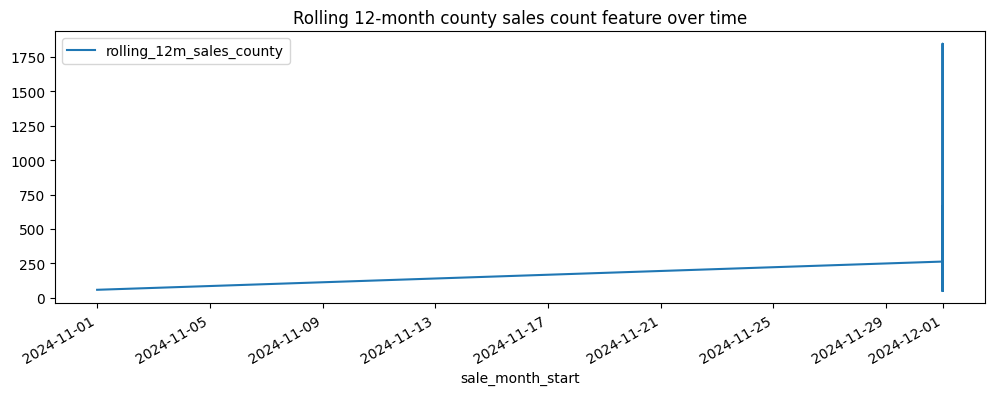

In [8]:
feature_df[['sale_month_start', 'rolling_12m_sales_county']].drop_duplicates().set_index('sale_month_start').tail(24).plot(
    figsize=(12, 4),
    title='Rolling 12-month county sales count feature over time'
)
plt.show()
